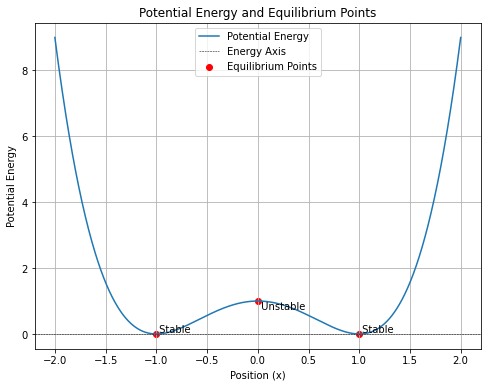

In [12]:
#1.1

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

V0 = 1.0  
d = 1.0   

def potential_energy(x):
    return V0 / (d**4) * (x**4 - 2 * x**2 * d**2 + d**4)

def potential_derivative(x):
    return 4 * V0 / (d**4) * x * (x**2 - d**2)

equilibrium_points = fsolve(potential_derivative, [-1, 0, 1])

x_values = np.linspace(-2, 2, 1000)
energy_values = potential_energy(x_values)

plt.figure(figsize=(8, 6))
plt.plot(x_values, energy_values, label='Potential Energy')
plt.scatter(equilibrium_points, potential_energy(equilibrium_points), color='red', label='Equilibrium Points')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5, label='Energy Axis')

for point in equilibrium_points:
    stability = "Stable" if potential_derivative(point + 0.01) > 0 else "Unstable"
    plt.text(point, potential_energy(point), f' {stability}', verticalalignment='bottom' if stability == "Stable" else 'top')

plt.title('Potential Energy and Equilibrium Points')
plt.xlabel('Position (x)')
plt.ylabel('Potential Energy')
plt.legend()
plt.grid(True)
plt.show()


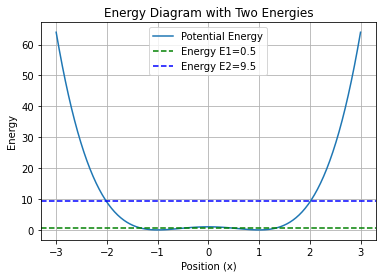

In [41]:
#1.2

def potential_energy(x, V0, d):
    return (V0 / d**4) * (x**4 - 2 * x**2 * d**2 + d**4)

def derivative_potential(x, V0, d):
    return (V0 / d**4) * (4 * x**3 - 4 * x * d**2)

x_values = np.linspace(-3, 3, 100)
V0_value = 1  
d_value = 1   
potential_values = potential_energy(x_values, V0_value, d_value)

E1 = 0.5  
E2 = 9.5  


plt.plot(x_values, potential_values, label='Potential Energy')
plt.axhline(E1, color='green', linestyle='--', label=f'Energy E1={E1}')
plt.axhline(E2, color='blue', linestyle='--', label=f'Energy E2={E2}')
plt.xlabel('Position (x)')
plt.ylabel('Energy')
plt.title('Energy Diagram with Two Energies')
plt.legend()
plt.grid(True)
plt.show()

# 2.

# E1 the particle oscillates between the potential energy well moving back and fortth with the wells.
# E2 overcomes potential barrier and potential wells. The motion is the particle escaping with an oscillation free trajectory

In [14]:
# 1.3

from scipy.optimize import fsolve

V0 = 1.0 
d = 1.0   

# Energy at x = 2d (initial position)
E_initial = V0 / d**4 * ((2 * d)**4 - 2 * (2 * d)**2 * d**2 + d**4)

# Function to find velocity at x = d
def find_velocity_at_d(v):
    return E_initial - V0 / d**4 * (d**4 - 2 * d**2 * d**2 + d**4) - 0.5 * v**2

# Improved initial guess for velocity at x = d
initial_guess_velocity_at_d = 0.9 * np.sqrt(2 * E_initial)

# Solving for velocity at x = d with improved initial guess
velocity_at_d = np.sqrt(fsolve(find_velocity_at_d, initial_guess_velocity_at_d)[0])

# Energy at x = -d (final position)
E_final = V0 / d**4 * ((-d)**4 - 2 * (-d)**2 * d**2 + d**4)

# Function to find initial velocity at x = d for reaching x = -d
def find_initial_velocity_for_reach(v):
    return E_final - V0 / d**4 * (-d**4 - 2 * (-d)**2 * d**2 + d**4) - 0.5 * v**2

# Improved initial guess for initial velocity at x = d for reaching x = -d
initial_guess_velocity_for_reach = 0.9 * np.sqrt(2 * E_final)

# Solving for initial velocity at x = d for reaching x = -d with improved initial guess
initial_velocity_for_reach = np.sqrt(fsolve(find_initial_velocity_for_reach, initial_guess_velocity_for_reach)[0])

print(f"Velocity at x = d when starting at rest at x = 2d: {velocity_at_d}")
print(f"Initial velocity at x = d for reaching x = -d: {initial_velocity_for_reach}")


Velocity at x = d when starting at rest at x = 2d: 2.0597671439071177
Initial velocity at x = d for reaching x = -d: 0.0


In [15]:
#1.4

import sympy as sp

x, V0, d = sp.symbols('x V0 d')

V = V0 / d**4 * (x**4 - 2*x**2 * d**2 + d**4)

force = -sp.diff(V, x)

m = sp.symbols('m')  
acceleration = force / m

print(f"Force acting on the particle: {force}")
print(f"Acceleration acting on the particle: {acceleration}")


Force acting on the particle: -V0*(-4*d**2*x + 4*x**3)/d**4
Acceleration acting on the particle: -V0*(-4*d**2*x + 4*x**3)/(d**4*m)


In [18]:
#1.5

y, z = sp.symbols('y z')

# force vector
force_vector = sp.Matrix([force, 0, 0])

# position vector
position_vector = sp.Matrix([x, y, z])

# curl of the force
curl_force = sp.Matrix([sp.diff(force_vector[2], y) - sp.diff(force_vector[1], z),
                       sp.diff(force_vector[0], z) - sp.diff(force_vector[2], x),
                       sp.diff(force_vector[1], x) - sp.diff(force_vector[0], y)])

print(f"Curl of the force: {curl_force}")


Curl of the force: Matrix([[0], [0], [0]])


In [21]:
# Define symbols
t = sp.symbols('t')
x_function = sp.Function('x')(t)
v_function = sp.Function('v')(t)

# linear momentum and angular momentum
linear_momentum = m * v_function
angular_momentum = m * x_function * v_function

# Differentiate linear momentum with respect to time (t)
d_linear_momentum_dt = sp.diff(linear_momentum, t)

# Display linear momentum and its time derivative
print(f"Linear Momentum: {linear_momentum}")
print(f"Time Derivative of Linear Momentum: {d_linear_momentum_dt}")

# Calculate angular momentum and its time derivative
d_angular_momentum_dt = sp.diff(angular_momentum, t)

print(f"Angular Momentum: {angular_momentum}")
print(f"Time Derivative of Angular Momentum: {d_angular_momentum_dt}")


Linear Momentum: m*v(t)
Time Derivative of Linear Momentum: m*Derivative(v(t), t)
Angular Momentum: m*v(t)*x(t)
Time Derivative of Angular Momentum: m*v(t)*Derivative(x(t), t) + m*x(t)*Derivative(v(t), t)


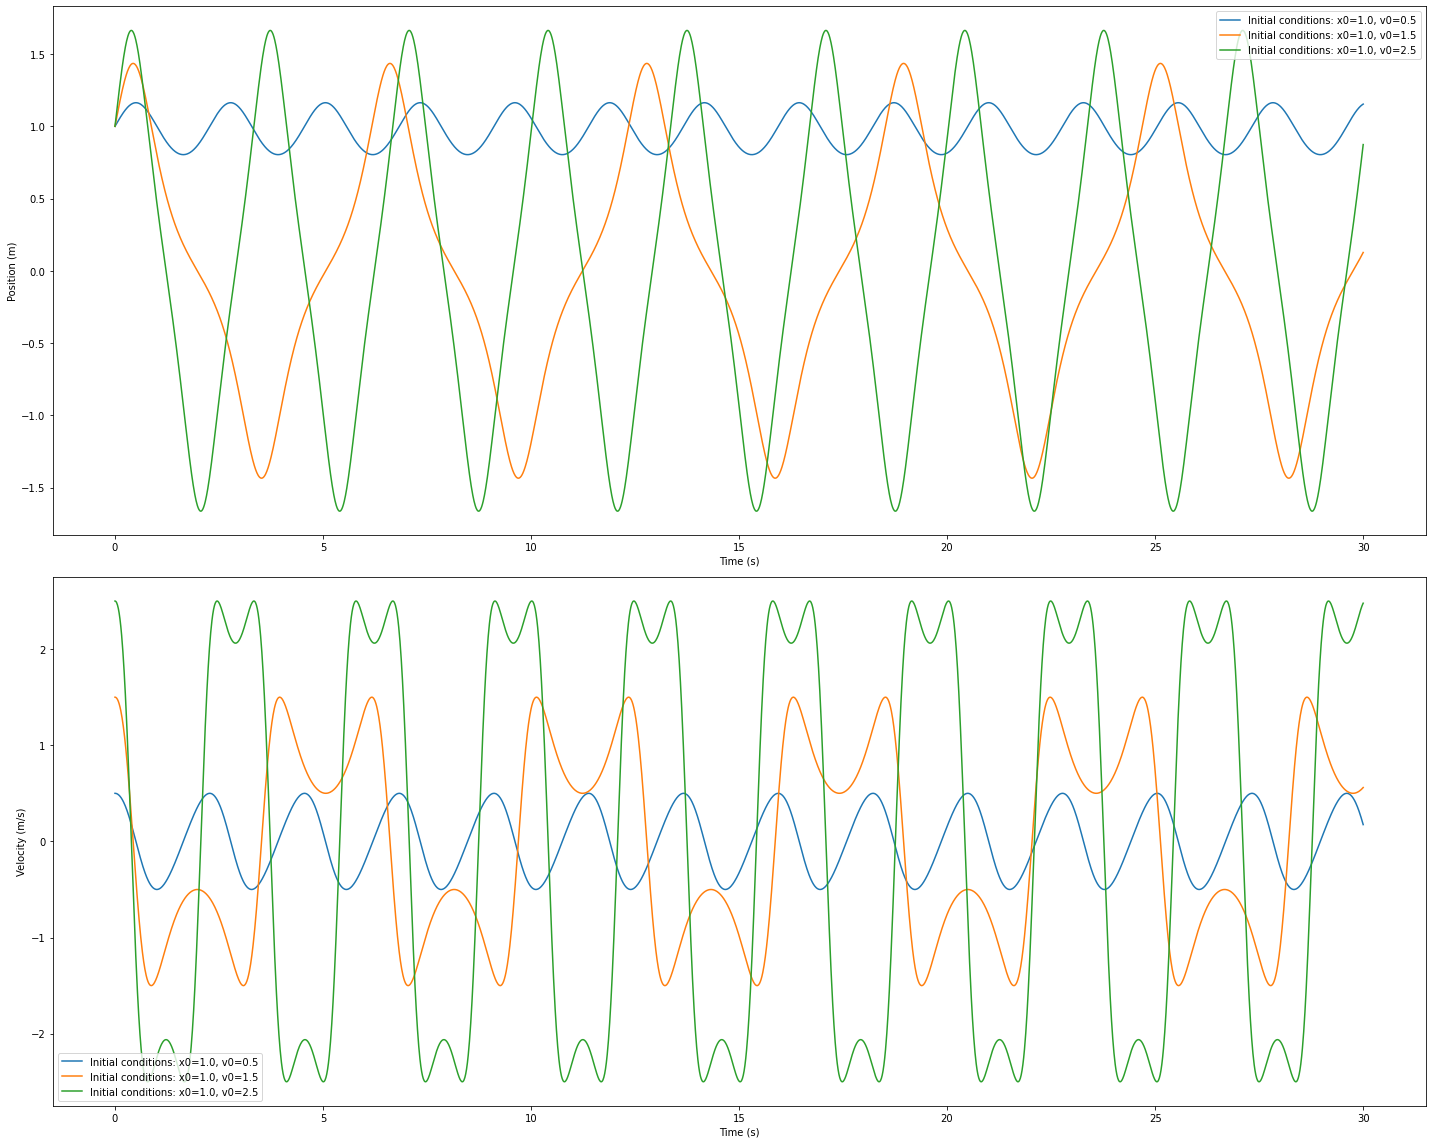

In [49]:
# 7,8,9


def potential_force(x, V0, d):
    return -4 * V0 / d**4 * (x**3 - x * d**2)

def velocity_verlet(x0, v0, dt, end_time, m, V0, d):
    num_steps = int(end_time / dt) + 1
    times = np.linspace(0, end_time, num_steps)
    positions = np.zeros_like(times)
    velocities = np.zeros_like(times)

    x, v = x0, v0

    for i, t in enumerate(times):
        positions[i] = x
        velocities[i] = v

        a = potential_force(x, V0, d) / m

        x += v * dt + 0.5 * a * dt**2
        a_new = potential_force(x, V0, d) / m
        v += 0.5 * (a + a_new) * dt

    return times, positions, velocities

m = 1.0
V0 = 1.0
d = 1.0
dt = 0.01
end_time = 30.0

x0_1, v0_1 = d, 0.5
x0_2, v0_2 = d, 1.5
x0_3, v0_3 = d, 2.5

times, pos_1, vel_1 = velocity_verlet(x0_1, v0_1, dt, end_time, m, V0, d)
_, pos_2, vel_2 = velocity_verlet(x0_2, v0_2, dt, end_time, m, V0, d)
_, pos_3, vel_3 = velocity_verlet(x0_3, v0_3, dt, end_time, m, V0, d)

plt.figure(figsize=(20, 16))

plt.subplot(2, 1, 1)
plt.plot(times, pos_1, label=f'Initial conditions: x0={x0_1}, v0={v0_1}')
plt.plot(times, pos_2, label=f'Initial conditions: x0={x0_2}, v0={v0_2}')
plt.plot(times, pos_3, label=f'Initial conditions: x0={x0_3}, v0={v0_3}')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(times, vel_1, label=f'Initial conditions: x0={x0_1}, v0={v0_1}')
plt.plot(times, vel_2, label=f'Initial conditions: x0={x0_2}, v0={v0_2}')
plt.plot(times, vel_3, label=f'Initial conditions: x0={x0_3}, v0={v0_3}')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()

plt.tight_layout()
plt.show()


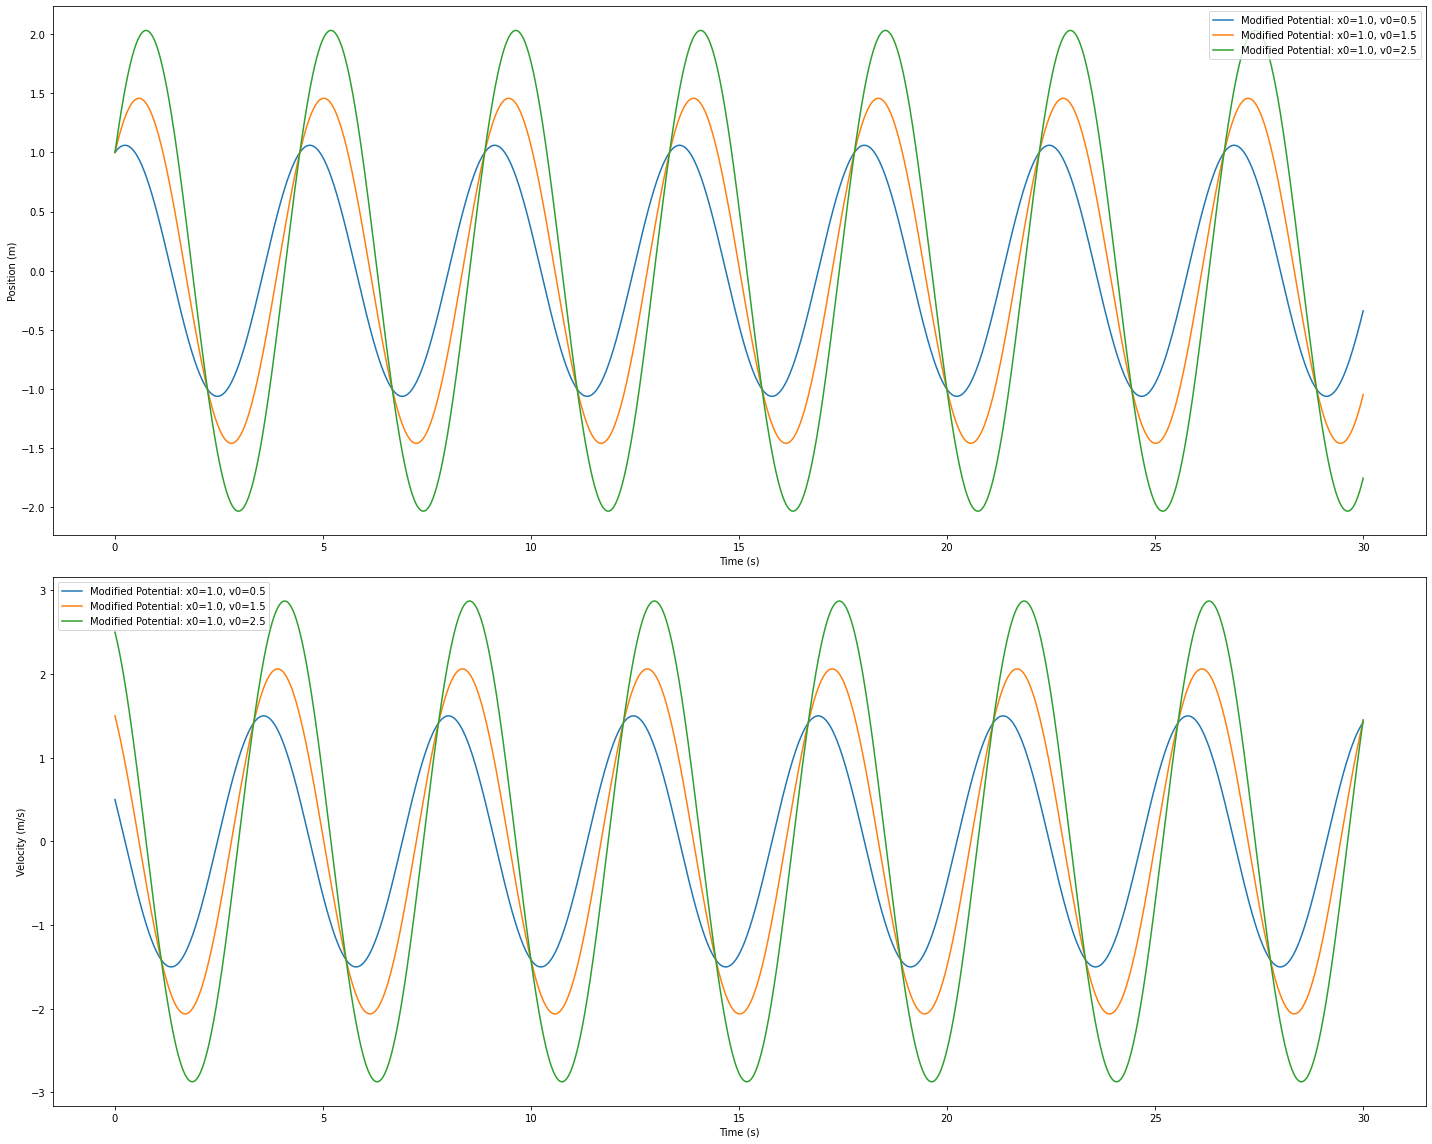

In [50]:

def modified_potential_force(x, V0, d):
    return -2 * V0 / d**2 * x

def modified_velocity_verlet(x0, v0, dt, end_time, m, V0, d):
    num_steps = int(end_time / dt) + 1
    times = np.linspace(0, end_time, num_steps)
    positions = np.zeros_like(times)
    velocities = np.zeros_like(times)

    x, v = x0, v0

    for i, t in enumerate(times):
        positions[i] = x
        velocities[i] = v

        a = modified_potential_force(x, V0, d) / m

        x += v * dt + 0.5 * a * dt**2
        a_new = modified_potential_force(x, V0, d) / m
        v += 0.5 * (a + a_new) * dt

    return times, positions, velocities

_, pos_1_mod, vel_1_mod = modified_velocity_verlet(x0_1, v0_1, dt, end_time, m, V0, d)
_, pos_2_mod, vel_2_mod = modified_velocity_verlet(x0_2, v0_2, dt, end_time, m, V0, d)
_, pos_3_mod, vel_3_mod = modified_velocity_verlet(x0_3, v0_3, dt, end_time, m, V0, d)

plt.figure(figsize=(20, 16))

plt.subplot(2, 1, 1)
plt.plot(times, pos_1_mod, label=f'Modified Potential: x0={x0_1}, v0={v0_1}')
plt.plot(times, pos_2_mod, label=f'Modified Potential: x0={x0_2}, v0={v0_2}')
plt.plot(times, pos_3_mod, label=f'Modified Potential: x0={x0_3}, v0={v0_3}')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(times, vel_1_mod, label=f'Modified Potential: x0={x0_1}, v0={v0_1}')
plt.plot(times, vel_2_mod, label=f'Modified Potential: x0={x0_2}, v0={v0_2}')
plt.plot(times, vel_3_mod, label=f'Modified Potential: x0={x0_3}, v0={v0_3}')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()

plt.tight_layout()
plt.show()

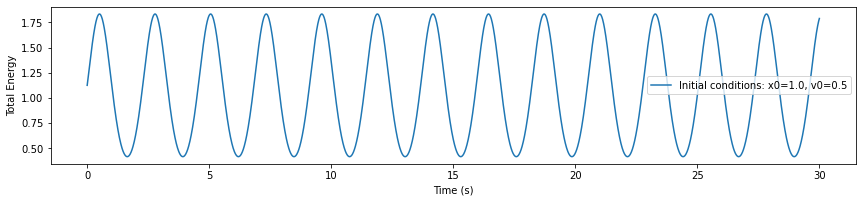

In [51]:

kinetic_energy_1 = 0.5 * m * vel_1**2
potential_energy_1 = V0 * (pos_1 / d)**4
total_energy_1 = kinetic_energy_1 + potential_energy_1

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(times, total_energy_1, label=f'Initial conditions: x0={x0_1}, v0={v0_1}')
plt.xlabel('Time (s)')
plt.ylabel('Total Energy')
plt.legend()


plt.tight_layout()
plt.show()


#
x_
0
​
 =d, 
v_
0
=
0.5
 
m/s
v 
0
​
 =0.5m/s:

The particle starts slightly displaced from the equilibrium position with a small initial velocity.
The motion is oscillatory around the equilibrium point.
Energy remains relatively constant with small oscillations.
x_
0
=
d
x 
0
​
 =d, 
v_
0
=
1.5
 
m/s
v 
0
​
 =1.5m/s:

The particle starts at equilibrium but with a higher initial velocity.
The motion shows larger oscillations around the equilibrium point.
Energy is conserved but with larger oscillations compared to the first case.
x
0
=
d
x 
0
​
 =d, 
V
0
=
2.5
 
m/s
v 
0
​
 =2.5m/s:

The particle starts at equilibrium with a significantly higher initial velocity.
The motion exhibits larger and faster oscillations.
Energy oscillates but shows a more noticeable increase over time.


In [ ]:
# Part 2

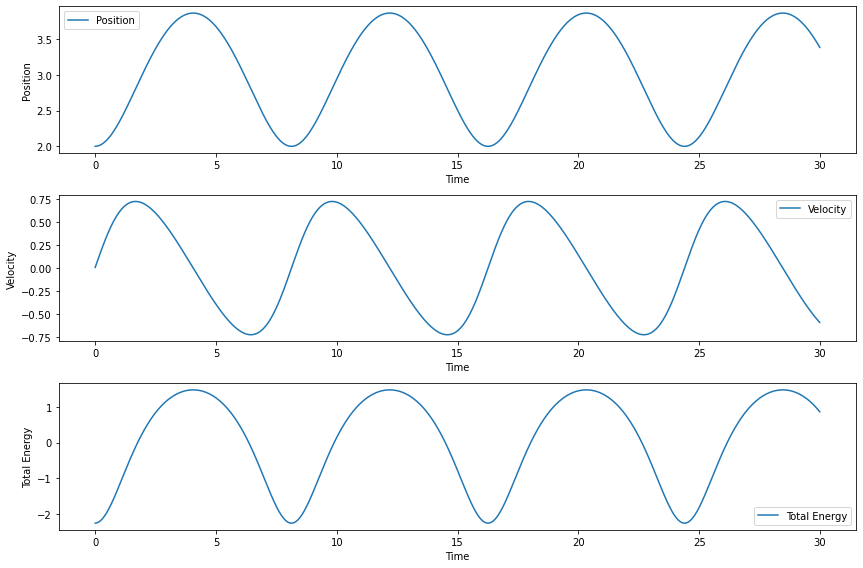

In [33]:
# 2.2

m = 1.0
x0 = 2.0
v0 = 0.0
dt = 0.01
times = np.arange(0, 30, dt)


positions = []
velocities = []
energies = []

x = x0
v = v0

for t in times:

    force = gamma/x**2 - 2*delta/x**3 - kappa

    x = x + v * dt + 0.5 * force / m * dt**2
    new_force = gamma/x**2 - 2*delta/x**3 - kappa  
    v = v + 0.5 * (force + new_force) / m * dt
    
    positions.append(x)
    velocities.append(v)
    energies.append(0.5 * m * v**2 + potential(x))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(times, positions, label='Position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(times, velocities, label='Velocity')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(times, energies, label='Total Energy')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.legend()

plt.tight_layout()
plt.show()


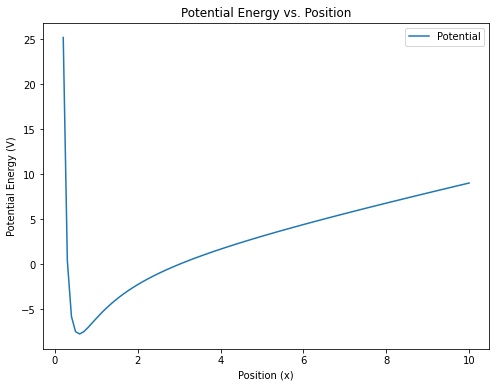

The minimum of the potential occurs at x = 0.595959595959596


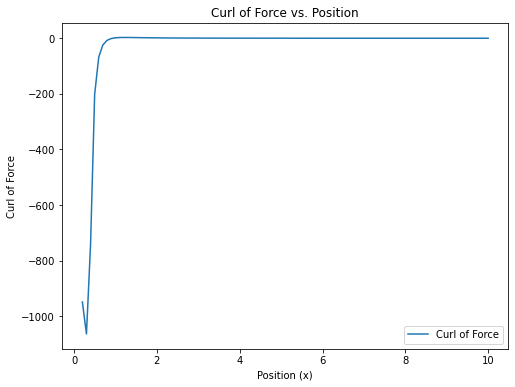

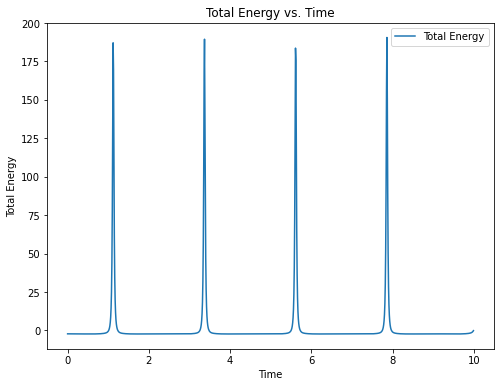

In [43]:
# 2.3

# Constants
gamma = 10
delta = 3
kappa = 1

# Part 2.1: Plot the potential
x_values = np.linspace(0.2, 10, 100)
potential_values = -gamma / x_values + delta / x_values**2 + kappa * x_values

plt.figure(figsize=(8, 6))
plt.plot(x_values, potential_values, label='Potential')
plt.title('Potential Energy vs. Position')
plt.xlabel('Position (x)')
plt.ylabel('Potential Energy (V)')
plt.legend()
plt.show()

# Part 2.2:
min_index = np.argmin(potential_values)
min_position = x_values[min_index]
print(f'The minimum of the potential occurs at x = {min_position}')

# Part 2.3:
force = -np.gradient(potential_values, x_values)
curl_of_force = np.gradient(force, x_values)

plt.figure(figsize=(8, 6))
plt.plot(x_values, curl_of_force, label='Curl of Force')
plt.title('Curl of Force vs. Position')
plt.xlabel('Position (x)')
plt.ylabel('Curl of Force')
plt.legend()
plt.show()

# Part 4: Velocity-Verlet method
def velocity_verlet(x0, v0, dt, num_steps):
    positions = np.zeros(num_steps)
    velocities = np.zeros(num_steps)
    
    positions[0] = x0
    velocities[0] = v0
    
    for i in range(1, num_steps):
       
        current_force = -gamma / positions[i - 1] + delta / positions[i - 1]**2 + kappa * positions[i - 1]
        
        positions[i] = positions[i - 1] + velocities[i - 1] * dt + 0.5 * current_force / m * dt**2
        
        new_force = -gamma / positions[i] + delta / positions[i]**2 + kappa * positions[i]
        
       
        velocities[i] = velocities[i - 1] + 0.5 * (current_force + new_force) / m * dt
    
    return positions, velocities

x0 = 2
v0 = 0
m = 1  


dt = 0.01
num_steps = 1000

positions, velocities = velocity_verlet(x0, v0, dt, num_steps)


kinetic_energy = 0.5 * m * velocities**2
potential_energy = -gamma / positions + delta / positions**2 + kappa * positions
total_energy = kinetic_energy + potential_energy

plt.figure(figsize=(8, 6))
plt.plot(np.arange(num_steps) * dt, total_energy, label='Total Energy')
plt.title('Total Energy vs. Time')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.legend()
plt.show()


In [38]:
# 2.3: turning points
x_at_rest = 2

potential_energy_at_rest = -gamma / x_at_rest + delta / x_at_rest**2 + kappa * x_at_rest
kinetic_energy_at_rest = 0.5 * m * v0**2
total_energy_at_rest = potential_energy_at_rest + kinetic_energy_at_rest

print(f'Total energy at x=2 (particle at rest): {total_energy_at_rest}')

turning_point_1 = np.sqrt(delta / kappa)  
turning_point_2 = -np.sqrt(delta / kappa)  

print(f'Turning Point 1: x = {turning_point_1}')
print(f'Turning Point 2: x = {turning_point_2}')

if total_energy_at_rest < potential_energy_at_rest:
    print("Particle is in a bound state, oscillating back and forth.")
else:
    print("Particle has enough energy to escape the potential well.")


Total energy at x=2 (particle at rest): -2.25
Turning Point 1: x = 1.7320508075688772
Turning Point 2: x = -1.7320508075688772
Particle has enough energy to escape the potential well.


The analysis at \(x = 2\) reveals the total energy of the particle in the potential well. The motion can be described based on the comparison between the total energy and the potential energy at \(x = 2\).

1. If the total energy is less than the potential energy at \(x = 2\):
   - The particle is in a bound state within the potential well.
   - It will oscillate back and forth around the minimum of the potential.
   - The turning points, where kinetic energy is zero, determine the amplitude of these oscillations.

2. If the total energy is equal to or greater than the potential energy at \(x = 2\):
   - The particle has enough energy to escape the potential well.
   - It will move away from the minimum of the potential and exhibit unbounded motion.

 motion depends on the energy state of the particle. If it has insufficient energy to overcome the potential barrier, it will oscillate within the well. If it has enough energy, it will escape and move away from the well. The turning points represent the limits of the oscillatory motion within the well.
